In [25]:
import h5py
import numpy as np

def compare_hdf5_files(file1, file2, rtol=1e-8, atol=1e-12):
    """
    Compare two GIZMO HDF5 IC files robustly, checking shapes first.
    """
    f1 = h5py.File(file1, 'r')
    f2 = h5py.File(file2, 'r')

    def compare_groups(g1, g2, path="/"):
        for key in g1:
            if key not in g2:
                print(f"Missing key in second file: {path}{key}")
                continue
            item1 = g1[key]
            item2 = g2[key]

            if isinstance(item1, h5py.Group):
                compare_groups(item1, item2, path + key + "/")
            elif isinstance(item1, h5py.Dataset):
                d1 = item1[()]
                d2 = item2[()]
                if d1.shape != d2.shape:
                    print(f"Shape mismatch at {path}{key}: {d1.shape} vs {d2.shape}")
                    continue
                if not np.allclose(d1, d2, rtol=rtol, atol=atol):
                    print(f"Dataset differs at {path}{key}")
            else:
                print(f"Unknown item type at {path}{key}")

        # Compare attributes
        for attr in g1.attrs:
            if attr not in g2.attrs:
                print(f"Missing attribute in second file: {path}{attr}")
                continue
            v1 = g1.attrs[attr]
            v2 = g2.attrs[attr]
            if isinstance(v1, np.ndarray):
                if v1.shape != v2.shape:
                    print(f"Attribute shape mismatch at {path}{attr}: {v1.shape} vs {v2.shape}")
                    continue
                if not np.allclose(v1, v2, rtol=rtol, atol=atol):
                    print(f"Attribute differs at {path}{attr}")
            else:
                if v1 != v2:
                    print(f"Attribute differs at {path}{attr}")

    compare_groups(f1, f2)
    print("Comparison complete.")
    f1.close()
    f2.close()

def summarize_differences(file1, file2):
    with h5py.File(file1,'r') as f1, h5py.File(file2,'r') as f2:
        for key in f1['/PartType0']:
            d1 = f1['/PartType0'][key][()]
            d2 = f2['/PartType0'][key][()]
            # print(d1,d2) #particle id is different becuase i used array length instead of 1e8
            if d1.shape != d2.shape:
                print(f"{key}: shape {d1.shape} vs {d2.shape}")
            else:
                diff = d1 - d2
                if np.issubdtype(diff.dtype, np.floating):
                    print(f"{key}: max diff = {np.max(np.abs(diff))}, mean diff = {np.mean(np.abs(diff))}")
                else:
                    n_diff = np.sum(d1 != d2)
                    print(f"{key}: {n_diff} entries differ")

summarize_differences("n85_0.hdf5","n85.hdf5")

CompositionType: shape (1677709,) vs (1677714,)
Coordinates: shape (1677709, 3) vs (1677714, 3)
Entropy: shape (1677709,) vs (1677714,)
InternalEnergy: shape (1677709,) vs (1677714,)
Masses: shape (1677709,) vs (1677714,)
ParticleIDs: shape (1677709,) vs (1677714,)
Temperature: shape (1677709,) vs (1677714,)
Velocities: shape (1677709, 3) vs (1677714, 3)


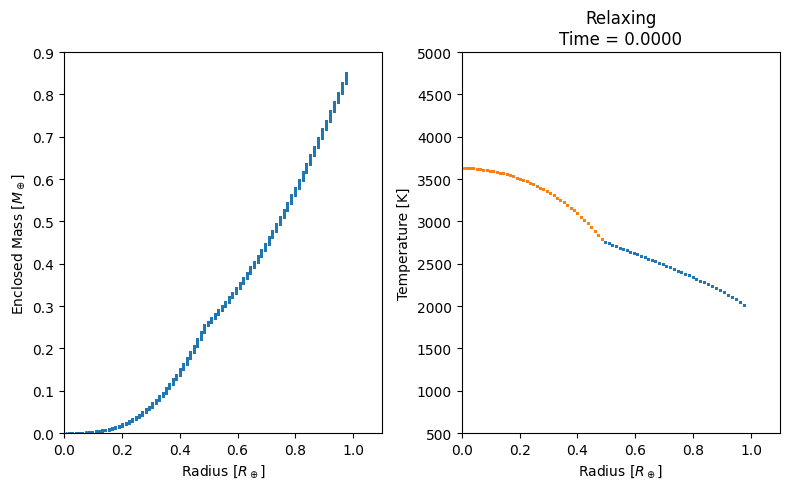

In [26]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

R_earth = 6.371e6
M_earth = 5.9724e24
mass_unit = 1/62.46  # GIZMO mass unit
gamma = 1.3          # approximate gamma for silicates/iron

fname = 'n85.hdf5'
# fname = f"{datadir}/snapshot_{i:03d}.hdf5"

with h5py.File(fname,'r') as f:
    pos = f['/PartType0/Coordinates'][()]   # code units
    m = f['/PartType0/Masses'][()]         # code units
    temp = f['/PartType0/Temperature'][()]
    compid = f['/PartType0/CompositionType'][()]
    time = f["Header"].attrs["Time"]
# Convert to physical units
r = np.linalg.norm(pos, axis=1)
m_phys = m * mass_unit    

# Sort by radius for cumulative mass
sort_idx = np.argsort(r)
r_sorted = r[sort_idx]
m_sorted = m_phys[sort_idx]

m_enc = np.cumsum(m_sorted)
unique_comp = np.unique(compid)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(8,5))
plt.title(f"Relaxing\nTime = {time:.4f}")
ax[0].plot(r_sorted, m_enc, '.', ms=1)
ax[0].set_xlabel(r"Radius [$R_\oplus]$")
ax[0].set_ylabel(r"Enclosed Mass $[M_\oplus]$")

for compi in unique_comp:
    mask = compid==compi
    ax[1].scatter(r[mask], temp[mask], s=1, alpha=0.6)
ax[1].set_xlabel(r"Radius [$R_\oplus]$")
ax[1].set_ylabel("Temperature [K]")

ax[0].set_xlim(0,1.1)
ax[0].set_ylim(0,0.9)

ax[1].set_xlim(0,1.1)
ax[1].set_ylim(500, 5000)

plt.tight_layout()

In [27]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

R_earth = 6.371e6
M_earth = 5.9724e24
mass_unit = 1/62.46  # GIZMO mass unit
gamma = 1.3          # approximate gamma for silicates/iron

snap_start = 0
snap_end   = 70
datadir = 'data'
plotdir = 'plot'
# -------- loop snapshots --------
for i in range(snap_start, snap_end + 1):
    # fname = 'n85_gizmo.hdf5'
    fname = f"{datadir}/snapshot_{i:03d}.hdf5"
    outname = f"{plotdir}/frame_{i:03d}.png"

    if not os.path.exists(fname):
        print(f"Missing {fname}, skip")
        continue
    if os.path.exists(outname):
        print(f"Existing {outname}, skip")
        continue
    with h5py.File(fname,'r') as f:
        pos = f['/PartType0/Coordinates'][()]   # code units
        m = f['/PartType0/Masses'][()]         # code units
        temp = f['/PartType0/Temperature'][()]
        compid = f['/PartType0/CompositionType'][()]
        time = f["Header"].attrs["Time"]
    # Convert to physical units
    r = np.linalg.norm(pos, axis=1)
    m_phys = m * mass_unit    

    # Sort by radius for cumulative mass
    sort_idx = np.argsort(r)
    r_sorted = r[sort_idx]
    m_sorted = m_phys[sort_idx]

    m_enc = np.cumsum(m_sorted)
    unique_comp = np.unique(compid)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(8,5))
    plt.title(f"Relaxing\nTime = {time:.4f}")
    ax[0].plot(r_sorted, m_enc, '.', ms=1)
    ax[0].set_xlabel(r"Radius [$R_\oplus]$")
    ax[0].set_ylabel(r"Enclosed Mass $[M_\oplus]$")

    for compi in unique_comp:
        mask = compid==compi
        ax[1].scatter(r[mask], temp[mask], s=1, alpha=0.6)
    ax[1].set_xlabel(r"Radius [$R_\oplus]$")
    ax[1].set_ylabel("Temperature [K]")

    ax[0].set_xlim(0,1.2)
    ax[0].set_ylim(0,0.9)

    ax[1].set_xlim(0,1.2)
    ax[1].set_ylim(500, 5000)

    plt.tight_layout()
    plt.savefig(outname, dpi=200)
    plt.close()
    print(f"Saved {outname}")

Saved plot/frame_000.png
Saved plot/frame_001.png
Saved plot/frame_002.png
Saved plot/frame_003.png
Saved plot/frame_004.png
Saved plot/frame_005.png
Saved plot/frame_006.png
Missing data/snapshot_007.hdf5, skip
Missing data/snapshot_008.hdf5, skip
Missing data/snapshot_009.hdf5, skip
Missing data/snapshot_010.hdf5, skip
Missing data/snapshot_011.hdf5, skip
Missing data/snapshot_012.hdf5, skip
Missing data/snapshot_013.hdf5, skip
Missing data/snapshot_014.hdf5, skip
Missing data/snapshot_015.hdf5, skip
Missing data/snapshot_016.hdf5, skip
Missing data/snapshot_017.hdf5, skip
Missing data/snapshot_018.hdf5, skip
Missing data/snapshot_019.hdf5, skip
Missing data/snapshot_020.hdf5, skip
Missing data/snapshot_021.hdf5, skip
Missing data/snapshot_022.hdf5, skip
Missing data/snapshot_023.hdf5, skip
Missing data/snapshot_024.hdf5, skip
Missing data/snapshot_025.hdf5, skip
Missing data/snapshot_026.hdf5, skip
Missing data/snapshot_027.hdf5, skip
Missing data/snapshot_028.hdf5, skip
Missing dat

In [9]:
import subprocess as sp
sp.run(["rm", "relaxing"+".mp4" ])
cmd = [
    "ffmpeg",
    "-r", "10",
    "-i", plotdir+"/frame_%03d.png",
    "-vcodec", "libx264",
    "-pix_fmt", "yuv420p",
    "relaxing"+".mp4"
]

sp.run(cmd, check=True)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

CompletedProcess(args=['ffmpeg', '-r', '10', '-i', 'plot/frame_%03d.png', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', 'relaxing.mp4'], returncode=0)

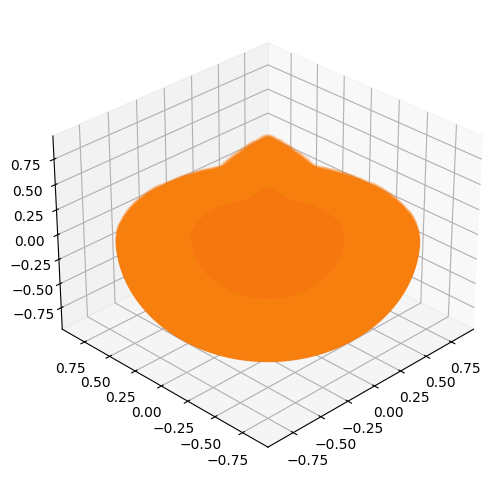

In [ ]:
x, y, z = pos[:,0], pos[:,1], pos[:,2]
# Convert to spherical coordinates
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arccos(z / r)           # polar angle: 0 at north pole
phi = np.arctan2(y, x)             # azimuthal angle: -pi to pi
phi = np.mod(phi, 2*np.pi)         # convert to 0 - 2pi

# Mask out the octant: theta in [0, pi/2], phi in [0, pi/2]
octant_mask = ~((theta >= 0) & (theta <= np.pi/2) & (phi >= 0) & (phi <= np.pi/2))

x_mask = x[octant_mask]
y_mask = y[octant_mask]
z_mask = z[octant_mask]
compid_mask = compid[octant_mask]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i,compi in enumerate(unique_comp):
    comp_indx = compid_mask==compi
    
    ax.scatter(x_mask[comp_indx], y_mask[comp_indx], z_mask[comp_indx], alpha=0.1)

ax.view_init(elev=30, azim=45)
# Optional: set equal aspect ratio in 3D (a bit tricky in Matplotlib)
max_range = (x_mask.max()-x_mask.min(), y_mask.max()-y_mask.min(), z_mask.max()-z_mask.min())
max_range_val = max(max_range)/2
mid_x = (x_mask.max()+x_mask.min())*0.5
mid_y = (y_mask.max()+y_mask.min())*0.5
mid_z = (z_mask.max()+z_mask.min())*0.5
ax.set_xlim(mid_x - max_range_val, mid_x + max_range_val)
ax.set_ylim(mid_y - max_range_val, mid_y + max_range_val)
ax.set_zlim(mid_z - max_range_val, mid_z + max_range_val)
plt.show()

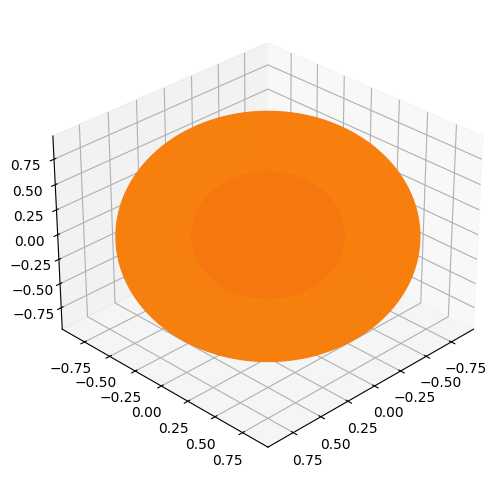

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original positions
x, y, z = pos[:,0], pos[:,1], pos[:,2]

# Convert to spherical coordinates
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arccos(z / r)           # polar angle: 0 at north pole
phi = np.arctan2(y, x)             # azimuthal angle: -pi to pi
phi = np.mod(phi, 2*np.pi)         # convert to 0 - 2pi

# Mask out the octant: theta in [0, pi/2], phi in [0, pi/2]
octant_mask = ~((theta >= 0) & (theta <= np.pi/2) & (phi >= 0) & (phi <= np.pi/2))

x_mask = x[octant_mask]
y_mask = y[octant_mask]
z_mask = z[octant_mask]
compid_mask = compid[octant_mask]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Camera view parameters
elev, azim = 30, 45
ax.view_init(elev=elev, azim=azim)

# Scatter per component, sorted by distance along camera direction
for i, compi in enumerate(unique_comp):
    comp_indx = compid_mask == compi
    x_c = x_mask[comp_indx]
    y_c = y_mask[comp_indx]
    z_c = z_mask[comp_indx]

    # Compute projection along camera direction
    dist = -((x_c-2)**2 + (y_c-2)**2 + (z_c-2)**2)
    sort_idx = np.argsort(dist)  # farthest first
    ax.scatter(x_c[sort_idx], y_c[sort_idx], z_c[sort_idx], alpha=0.1)

# Equal aspect ratio
max_range = np.array([x_mask.max()-x_mask.min(),
                      y_mask.max()-y_mask.min(),
                      z_mask.max()-z_mask.min()])
max_range_val = max(max_range)/2
mid_x = (x_mask.max()+x_mask.min())*0.5
mid_y = (y_mask.max()+y_mask.min())*0.5
mid_z = (z_mask.max()+z_mask.min())*0.5
ax.set_xlim(mid_x - max_range_val, mid_x + max_range_val)
ax.set_ylim(mid_y - max_range_val, mid_y + max_range_val)
ax.set_zlim(mid_z - max_range_val, mid_z + max_range_val)

plt.show()